Error: 'Alcohol_Sales.csv' not found. Please upload it to the Colab files pane.
Generating synthetic data for demonstration purposes...
Training the RNN model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


276/276 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0248
Epoch 2/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0143
Epoch 3/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0098
Epoch 4/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0043
Epoch 5/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.2097e-04
Epoch 6/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.8866e-04
Epoch 7/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.7245e-04
Epoch 8/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.7519e-04
Epoch 9/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 7.6339e-05
Epoch 10/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 7.6251e-05
Epoch 11/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.2334e-04
Epoch 12/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0015    
Epoch 13/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.7074e-04
Epoch 14/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.5791e-04
Epoch 15/20
276/276 ━━━━━━

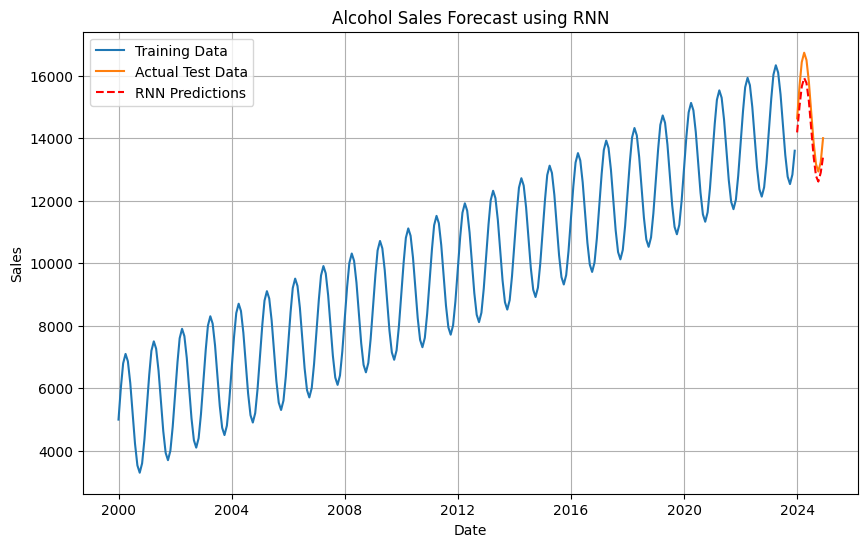

In [2]:
# --- RUN THIS IN A GOOGLE COLAB CELL ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# ---------------------------------------------------------
# 1. Load and Inspect the Data
# ---------------------------------------------------------
# Make sure your file is named 'Alcohol_Sales.csv' and uploaded to Colab.
# We set the 'DATE' column as the index and parse it as datetime objects.
try:
    df = pd.read_csv('Alcohol_Sales.csv', index_col='DATE', parse_dates=True)
    df.columns = ['Sales'] # Rename column for simplicity
except FileNotFoundError:
    print("Error: 'Alcohol_Sales.csv' not found. Please upload it to the Colab files pane.")
    # For demonstration, creating a dummy dataset if the file is missing so the code doesn't crash
    print("Generating synthetic data for demonstration purposes...")
    dates = pd.date_range(start='2000-01-01', periods=300, freq='MS')
    sales = np.linspace(5000, 15000, 300) + np.sin(np.arange(300) * (2 * np.pi / 12)) * 2000
    df = pd.DataFrame(sales, index=dates, columns=['Sales'])

# ---------------------------------------------------------
# 2. Train-Test Split
# ---------------------------------------------------------
# We will use the last 12 months for testing
n_obs = 12
train = df.iloc[:-n_obs]
test = df.iloc[-n_obs:]

# ---------------------------------------------------------
# 3. Scale the Data
# ---------------------------------------------------------
# Neural networks work best with normalized data (values between 0 and 1)
scaler = MinMaxScaler()
scaler.fit(train)

scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

# ---------------------------------------------------------
# 4. Create Time Series Generator
# ---------------------------------------------------------
# This generates batches of sequential data. It takes 'n_input' months
# to predict the next 1 month.
n_input = 12 # Look back 12 months
n_features = 1 # We are only predicting 'Sales'

generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

# ---------------------------------------------------------
# 5. Build the Recurrent Neural Network (LSTM)
# ---------------------------------------------------------
model = Sequential()

# LSTM is a powerful type of Recurrent Neural Network that avoids the
# vanishing gradient problem, making it perfect for yearly seasonality.
model.add(LSTM(100, activation='relu', input_shape=(n_input, n_features)))
model.add(Dense(1)) # Output layer predicting 1 value

model.compile(optimizer='adam', loss='mse')

# ---------------------------------------------------------
# 6. Train the Model
# ---------------------------------------------------------
print("Training the RNN model...")
# Fit the model (epochs=20 is a good starting point, adjust as needed)
model.fit(generator, epochs=20, verbose=1)

# ---------------------------------------------------------
# 7. Evaluate and Predict on Test Data
# ---------------------------------------------------------
test_predictions = []

# We need the last 'n_input' points from the training set to predict the first test point
first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):
    # Get prediction 1 time stamp ahead ([0] is for grabbing just the number instead of [array])
    current_pred = model.predict(current_batch, verbose=0)[0]

    # Store prediction
    test_predictions.append(current_pred)

    # Update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

# Inverse transform the scaled predictions back to real sales values
true_predictions = scaler.inverse_transform(test_predictions)

# Add predictions to the test dataframe
test = test.copy() # Avoid SettingWithCopyWarning
test['Predictions'] = true_predictions

# ---------------------------------------------------------
# 8. Plot the Results
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Sales'], label='Training Data')
plt.plot(test.index, test['Sales'], label='Actual Test Data')
plt.plot(test.index, test['Predictions'], label='RNN Predictions', color='red', linestyle='--')
plt.title('Alcohol Sales Forecast using RNN')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# Alcohol Sales Forecasting with LSTM
This notebook demonstrates time series forecasting using a Recurrent Neural Network (LSTM).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# 1. Load and Inspect the Data
try:
    df = pd.read_csv('Alcohol_Sales.csv', index_col='DATE', parse_dates=True)
    df.columns = ['Sales']
except FileNotFoundError:
    print("Error: 'Alcohol_Sales.csv' not found. Generating synthetic data...")
    dates = pd.date_range(start='2000-01-01', periods=300, freq='MS')
    sales = np.linspace(5000, 15000, 300) + np.sin(np.arange(300) * (2 * np.pi / 12)) * 2000
    df = pd.DataFrame(sales, index=dates, columns=['Sales'])

display(df.head())

Error: 'Alcohol_Sales.csv' not found. Generating synthetic data...


,Sales
2000-01-01,5000.000000
2000-02-01,6033.444816
2000-03-01,6798.940440
2000-04-01,7100.334448
2000-05-01,6865.830072


In [4]:
# 2. Train-Test Split & Scaling
n_obs = 12
train = df.iloc[:-n_obs]
test = df.iloc[-n_obs:]

scaler = MinMaxScaler()
scaler.fit(train)

scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

# 3. Time Series Generator
n_input = 12
n_features = 1
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

In [5]:
# 4. Build the LSTM Model
model = Sequential([
    Input(shape=(n_input, n_features)),
    LSTM(100, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 5. Train the Model
print("Training the RNN model...")
model.fit(generator, epochs=20, verbose=1)

Training the RNN model...
Epoch 1/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0247
Epoch 2/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0069
Epoch 3/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0012
Epoch 4/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.1272e-04
Epoch 5/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.6297e-04
Epoch 6/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.2213e-04
Epoch 7/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.0516e-04
Epoch 8/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.6776e-04
Epoch 9/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5.4119e-04
Epoch 10/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.5841e-04
Epoch 11/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.4434e-04
Epoch 12/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.2938e-04
Epoch 13/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5.2845e-04
Epoch 14/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - 

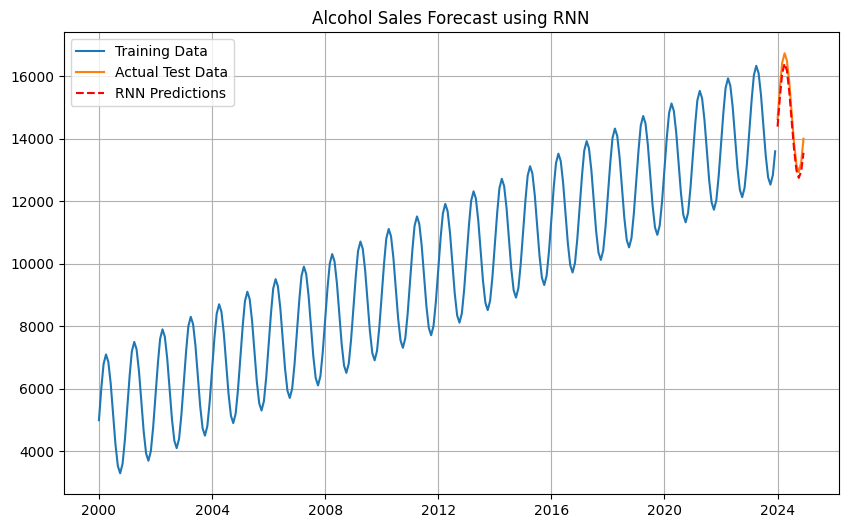

In [7]:
# 6. Evaluate and Predict
test_predictions = []
first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):
    current_pred = model.predict(current_batch, verbose=0)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

true_predictions = scaler.inverse_transform(test_predictions)
test = test.copy()
test['Predictions'] = true_predictions

# 7. Plot Results
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Sales'], label='Training Data')
plt.plot(test.index, test['Sales'], label='Actual Test Data')
plt.plot(test.index, test['Predictions'], label='RNN Predictions', color='red', linestyle='--')
plt.title('Alcohol Sales Forecast using RNN')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
print("\nModel Parameters (Weights and Biases):")
for i, layer in enumerate(model.layers):
    weights = layer.get_weights()
    if weights:
        print(f"\nLayer {i+1} ({layer.name}):")
        for j, w in enumerate(weights):
            if j % 2 == 0:
                print(f"  Weight {j//2 + 1} (shape: {w.shape}, type: {w.dtype})")
            else:
                print(f"  Bias {j//2 + 1} (shape: {w.shape}, type: {w.dtype})")



Model Parameters (Weights and Biases):

Layer 1 (lstm_1):
  Weight 1 (shape: (1, 400), type: float32)
  Bias 1 (shape: (100, 400), type: float32)
  Weight 2 (shape: (400,), type: float32)

Layer 2 (dense_1):
  Weight 1 (shape: (100, 1), type: float32)
  Bias 1 (shape: (1,), type: float32)
